# Baseline Model for Titer Prediction

Runs the baseline model comparison using the cleaned/feature-engineered per-experiment time series datasets

- Linear Regression
- Multiple Linear Regression (MLR) with top 5 features
- Multiple Linear Regression (MLR) with all features
- Ridge regression (L2-regularized)
- PLS regression
- Random Forest
- Gradient Boosting
- XGBoost

In [15]:
import pathlib

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

In [16]:
DATA_DIR = "../data"
train_exp = pd.read_csv(f"{DATA_DIR}/train_exp_features.csv", index_col="Exp")

feature_cols = [c for c in train_exp.columns if c not in ("Y:Titer", "n_days")]

print("train_exp:", train_exp.shape)
print(f"Using {len(feature_cols)} features")
train_exp.head()

train_exp: (100, 69)
Using 67 features


,n_days,Z:FeedStart,Z:FeedEnd,Z:FeedRateGlc,Z:FeedRateGln,Z:phStart,Z:phEnd,Z:phShift,Z:tempStart,Z:tempEnd,...,Lysed_final,Lysed_max,Lysed_mean,Lysed_auc,Lysed_slope,VCD_growth_rate,VCD_time_to_peak,temp_shift_reached,ph_shift_reached,Y:Titer
Exp,,,,,,,,,,,,,,,,,,,,,
Exp 1,10,2.0,10.0,5.656566,6.818182,6.808081,6.479798,9.0,37.282828,35.070707,...,0.282538,0.282538,0.059261,0.510602,0.022485,0.309023,10.0,False,True,2550.097032
Exp 2,10,1.0,12.0,5.696970,6.979798,6.606061,6.207071,8.0,37.121212,35.595960,...,0.230921,0.230921,0.046228,0.393049,0.018635,0.062388,6.0,True,True,1278.058508
Exp 3,9,3.0,11.0,3.030303,7.242424,6.585859,6.803030,8.0,37.565657,35.818182,...,0.039230,0.044257,0.012165,0.102039,0.003967,0.259017,9.0,True,True,1162.646534
Exp 4,9,2.0,12.0,4.484848,6.838384,6.717172,6.651515,12.0,37.787879,35.535354,...,0.089675,0.089675,0.016068,0.115842,0.006892,0.245739,8.0,False,False,1012.535606
Exp 5,8,3.0,11.0,5.090909,6.232323,7.424242,6.469697,13.0,36.979798,35.858586,...,0.043197,0.043197,0.013117,0.096457,0.004464,0.334355,8.0,True,False,1132.710237


## 1. Baseline modeling

With only 100 experiments and many of (collinear) engineered features, we here compare baseline regressors under repeated K-fold cross-validation on the train set.

In [17]:
X = train_exp[feature_cols].to_numpy()
y = train_exp["Y:Titer"].to_numpy()

# Top correlated features
_corr_sorted = (
    train_exp[feature_cols]
    .corrwith(train_exp["Y:Titer"])
    .abs()
    .sort_values(ascending=False)
)

best_5_features = _corr_sorted.head(5).index.tolist()
best_10_features = _corr_sorted.head(10).index.tolist()

X_top5 = train_exp[best_5_features].to_numpy()
X_top10 = train_exp[best_10_features].to_numpy()
X_best = X_top5[:, 0].reshape(-1, 1)
print(f"Top 5 features for MLR model: {best_5_features}")
print(f"Top 10 features for MLR model: {best_10_features}")

Top 5 features for MLR model: ['VCD_time_to_peak', 'Lysed_slope', 'Lysed_final', 'VCD_auc', 'Lysed_auc']
Top 10 features for MLR model: ['VCD_time_to_peak', 'Lysed_slope', 'Lysed_final', 'VCD_auc', 'Lysed_auc', 'Lac_auc', 'Z:ExpDuration', 'temp_auc', 'pH_auc', 'FeedGlc_auc']


In [18]:
models = {
    "LR": (
        Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
        X_best,
    ),
    "MLR_Top5": (
        Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
        X_top5,
    ),
    "MLR_Top10": (
        Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
        X_top10,
    ),
    "MLR": (
        Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
        X,
    ),
    "Ridge": (
        Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10.0))]),
        X,
    ),
    "PLS_5": (
        Pipeline(
            [
                ("scale", StandardScaler()),
                ("model", PLSRegression(n_components=5)),
            ]
        ),
        X,
    ),
    "RF": (
        RandomForestRegressor(n_estimators=300, max_depth=5, random_state=0),
        X,
    ),
    "GradientBoosting": (
        GradientBoostingRegressor(
            n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0
        ),
        X,
    ),
    "XGBoost": (
        XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0),
        X,
    ),
}

In [19]:
cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=0)

results = []
for name, (model, X_model) in models.items():
    scores = cross_validate(
        model,
        X_model,
        y,
        cv=cv,
        scoring=[
            "r2",
            "neg_mean_absolute_error",
            "neg_root_mean_squared_error",
        ],
    )
    rmse_mean = -scores["test_neg_root_mean_squared_error"].mean()
    results.append(
        {
            "model": name,
            "R2_mean": scores["test_r2"].mean(),
            "R2_std": scores["test_r2"].std(),
            "MAE_mean": -scores["test_neg_mean_absolute_error"].mean(),
            "RMSE_mean": rmse_mean,
            "RRMSE_mean": rmse_mean / y.mean(),
        }
    )

results_df = (
    pd.DataFrame(results).sort_values("R2_mean", ascending=False).reset_index(drop=True)
)
results_df

,model,R2_mean,R2_std,MAE_mean,RMSE_mean,RRMSE_mean
0,GradientBoosting,0.792505,0.087179,208.509774,320.806912,0.244051
1,Ridge,0.761608,0.155288,209.440215,329.780860,0.250878
2,RF,0.731105,0.124901,231.317837,362.531131,0.275792
3,XGBoost,0.726351,0.114448,222.791766,368.572387,0.280388
4,PLS_5,0.724387,0.173951,236.612884,352.335567,0.268036
5,MLR_Top10,0.700228,0.197731,252.643261,377.565174,0.287229
6,MLR,0.624332,0.252766,252.453032,402.696949,0.306348
7,LR,0.454314,0.313005,350.415814,505.047981,0.384211
8,MLR_Top5,0.404753,0.399546,342.504787,527.318550,0.401153


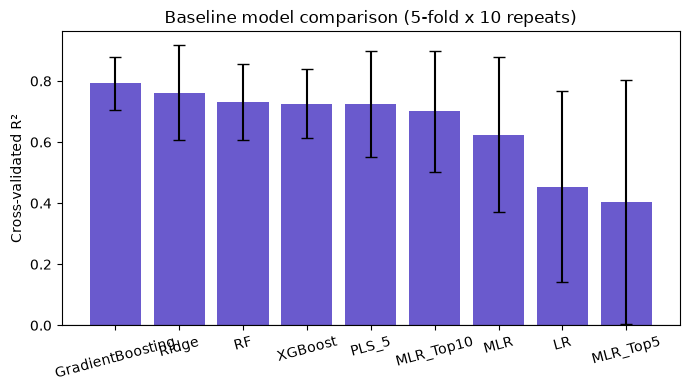

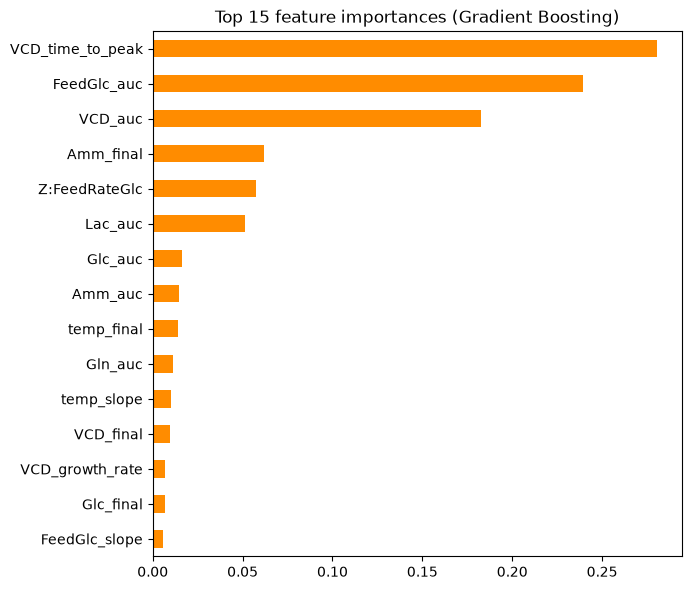

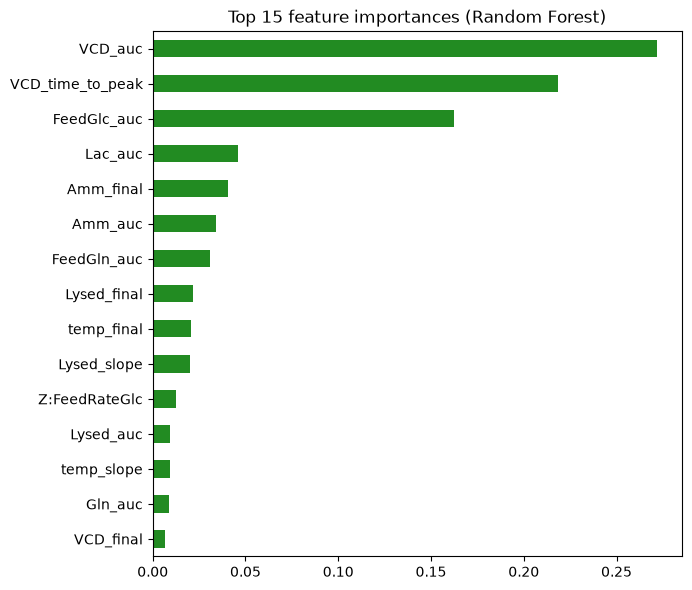

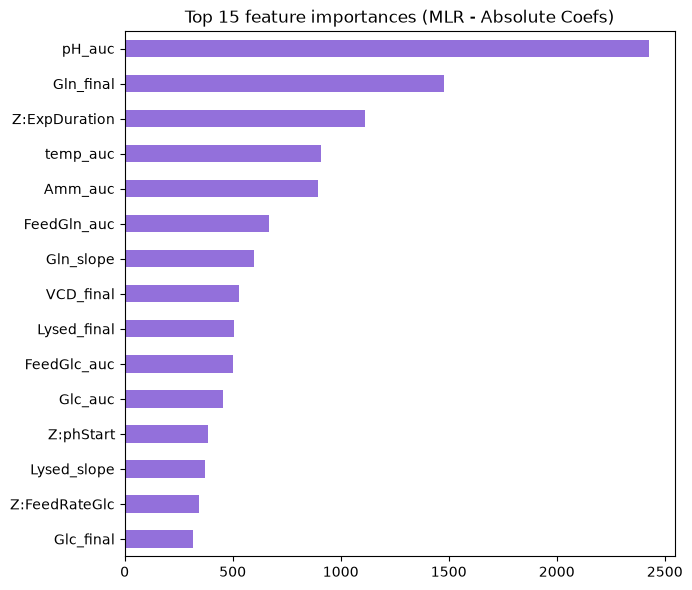

In [20]:
plt.figure(figsize=(7, 4))
plt.bar(
    results_df["model"],
    results_df["R2_mean"],
    yerr=results_df["R2_std"],
    capsize=4,
    color="slateblue",
)
plt.ylabel("Cross-validated R²")
plt.title("Baseline model comparison (5-fold x 10 repeats)")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Feature importance from the best tree-based model for interpretability
best_tree = GradientBoostingRegressor(
    n_estimators=200, max_depth=2, learning_rate=0.05, random_state=0
).fit(X, y)
importances = (
    pd.Series(best_tree.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(7, 6))
importances[::-1].plot.barh(color="darkorange")
plt.title("Top 15 feature importances (Gradient Boosting)")
plt.tight_layout()
plt.show()

# Feature importance from Random Forest
rf_tree = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=0).fit(X, y)
rf_importances = (
    pd.Series(rf_tree.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(7, 6))
rf_importances[::-1].plot.barh(color="forestgreen")
plt.title("Top 15 feature importances (Random Forest)")
plt.tight_layout()
plt.show()

# Feature importance from Multiple Linear Regression (MLR)
mlr_model = Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]).fit(
    X, y
)
mlr_importances = (
    pd.Series(np.abs(mlr_model.named_steps["model"].coef_), index=feature_cols)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(7, 6))
mlr_importances[::-1].plot.barh(color="mediumpurple")
plt.title("Top 15 feature importances (MLR - Absolute Coefs)")
plt.tight_layout()
plt.show()

In [21]:
# Train and save model
MODELS_DIR = pathlib.Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

for name, (model, X_model) in models.items():
    model.fit(X_model, y)
    filename = (
        MODELS_DIR
        / f"{name.replace(' ', '_').replace('(', '').replace(')', '')}.joblib"
    )
    joblib.dump(model, filename)